In [ ]:
# Train Baseline Model (Ab-Initio GNN)
This notebook trains a baseline GNN classifier from scratch without retrieval augmentation.

**Purpose:**
- Train a standard GNN classifier on TaoWu dataset
- Provides a fair comparison against the RAC model
- Uses same train/val split as RAC model (Script 04)
- Encoder initialized randomly (no pre-training on knowledge base)

# Import necessary libraries
import os
import torch
import pandas as pd
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from models import GraphAutoencoder, Baseline_GNN
from utils import FCDataset

# ===== DEFINE PATHS =====
output_dir = r'C:\Users\danie\Documents\Projects\Master thesis\Tara\Scripts\Outputs'
master_csv = os.path.join(output_dir, "master_metadata.csv")

# ===== LOAD AND SPLIT DATA =====
# Load master metadata
df = pd.read_csv(master_csv)

# Extract TaoWu dataset as target
df_target = df[df['dataset_source'] == 'TaoWu'].reset_index(drop=True)

# ===== CREATE TRAIN/VALIDATION SPLIT =====
# Use SAME random_state=42 as Script 04 for fair comparison
# 80% training, 20% validation
# Stratified split maintains class balance
df_train, df_val = train_test_split(df_target, test_size=0.2, stratify=df_target['label'], random_state=42)

# ===== CREATE DATALOADERS =====
# Same batch size as RAC model for consistency
train_loader = DataLoader(FCDataset(df_train), batch_size=16, shuffle=True)
val_loader = DataLoader(FCDataset(df_val), batch_size=16, shuffle=False)

# ===== INITIALIZE BASELINE MODEL FROM SCRATCH =====
# Create a FRESH GraphAutoencoder with RANDOM weights
# Unlike RAC, this encoder has NO pre-training on knowledge base
fresh_gae = GraphAutoencoder(num_nodes=100, input_dim=100, hidden_dim=64, embedding_dim=128)

# Initialize Baseline_GNN (encoder + classifier)
# This model learns everything from scratch using only TaoWu data
baseline_model = Baseline_GNN(gae_encoder=fresh_gae.encoder, embedding_dim=128)

# ===== TRAINING SETUP =====
# Optimizer updates ALL parameters (encoder + classifier)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

# Loss function: Binary Cross Entropy
# Note: Baseline_GNN ends with Sigmoid, so we use BCELoss
# (If Sigmoid was removed, would use BCEWithLogitsLoss for numerical stability)
loss_fn = torch.nn.BCELoss()

# ===== TRAINING LOOP =====
num_epochs = 50
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ===== TRAINING PHASE =====
    baseline_model.train()  # Enable training mode
    total_train_loss = 0
    
    for data, labels in train_loader:
        optimizer.zero_grad()  # Reset gradients
        
        # ===== FORWARD PASS =====
        # Process target data directly (NO retrieval step)
        # Input: node features, edge connections, edge weights, batch assignment
        # Output: Probability of PD (0 to 1)
        predictions = baseline_model(data.x, data.edge_index, data.edge_weight, data.batch)
        
        # ===== CALCULATE LOSS =====
        # Compare predictions with ground truth labels
        loss = loss_fn(predictions.squeeze(), labels.float())
        
        # ===== BACKPROPAGATION =====
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights
        
        total_train_loss += loss.item()

    # ===== VALIDATION PHASE =====
    baseline_model.eval()  # Disable dropout, etc.
    total_val_loss = 0
    correct = 0
    total = 0
    
    # No gradient computation for validation
    with torch.no_grad():
        for data, labels in val_loader:
            # Forward pass
            preds = baseline_model(data.x, data.edge_index, data.edge_weight, data.batch)
            
            # Calculate loss
            val_loss = loss_fn(preds.squeeze(), labels.float())
            total_val_loss += val_loss.item()
            
            # ===== CALCULATE ACCURACY =====
            # Convert probabilities to binary predictions (threshold = 0.5)
            predicted_class = (preds > 0.5).float()
            correct += (predicted_class.squeeze() == labels).sum().item()
            total += labels.size(0)

    # Calculate epoch metrics
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    
    # Store metrics for visualization
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

# ===== SAVE TRAINED MODEL =====
# Save baseline model weights for evaluation
torch.save(baseline_model.state_dict(), os.path.join(output_dir, 'baseline_model.pth'))
print("Baseline Model (Ab-Initio) Training Complete.")

# ===== VISUALIZATION =====
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training and validation loss
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Training Loss', linewidth=2)
ax1.plot(range(1, num_epochs + 1), val_losses, marker='s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Baseline Model Training & Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy over time
ax2.plot(range(1, num_epochs + 1), val_accuracies, marker='o', color='green', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Baseline Validation Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'baseline_training_metrics.png'), dpi=300)
plt.show()

# Print final training statistics
print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}% at Epoch {val_accuracies.index(max(val_accuracies)) + 1}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")

In [6]:
import os
import torch
import pandas as pd
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from models import GraphAutoencoder, Baseline_GNN
from utils import FCDataset

In [7]:
output_dir = r'C:\Users\danie\Documents\Projects\Master thesis\Tara\Scripts\Outputs'
master_csv = os.path.join(output_dir, "master_metadata.csv")

# 2. Load metadata, create train/val splits for TaoWu
#    - (Same as step 2 & 3 in script 04)

# 2. LOAD & SPLIT DATA (Same as Script 04 for consistency)
df = pd.read_csv(master_csv)
df_target = df[df['dataset_source'] == 'TaoWu'].reset_index(drop=True)

# 80/20 split - Use the same random_state=42 as Script 04
df_train, df_val = train_test_split(df_target, test_size=0.2, stratify=df_target['label'], random_state=42)

train_loader = DataLoader(FCDataset(df_train), batch_size=16, shuffle=True)
val_loader = DataLoader(FCDataset(df_val), batch_size=16, shuffle=False)

Epoch 1/50 | Train Loss: 0.7597 | Val Loss: 0.7008 | Val Acc: 50.00%
Epoch 2/50 | Train Loss: 0.7290 | Val Loss: 0.6865 | Val Acc: 50.00%
Epoch 3/50 | Train Loss: 0.7026 | Val Loss: 0.6863 | Val Acc: 50.00%
Epoch 4/50 | Train Loss: 0.6731 | Val Loss: 0.6828 | Val Acc: 50.00%
Epoch 5/50 | Train Loss: 0.6528 | Val Loss: 0.6777 | Val Acc: 50.00%
Epoch 6/50 | Train Loss: 0.6801 | Val Loss: 0.6669 | Val Acc: 50.00%
Epoch 7/50 | Train Loss: 0.6382 | Val Loss: 0.6536 | Val Acc: 50.00%
Epoch 8/50 | Train Loss: 0.6444 | Val Loss: 0.6380 | Val Acc: 62.50%
Epoch 9/50 | Train Loss: 0.6416 | Val Loss: 0.6270 | Val Acc: 62.50%
Epoch 10/50 | Train Loss: 0.6171 | Val Loss: 0.6135 | Val Acc: 62.50%
Epoch 11/50 | Train Loss: 0.5859 | Val Loss: 0.5935 | Val Acc: 75.00%
Epoch 12/50 | Train Loss: 0.5596 | Val Loss: 0.5848 | Val Acc: 62.50%
Epoch 13/50 | Train Loss: 0.5312 | Val Loss: 0.5620 | Val Acc: 75.00%
Epoch 14/50 | Train Loss: 0.5397 | Val Loss: 0.5215 | Val Acc: 75.00%
Epoch 15/50 | Train Loss: 0.5

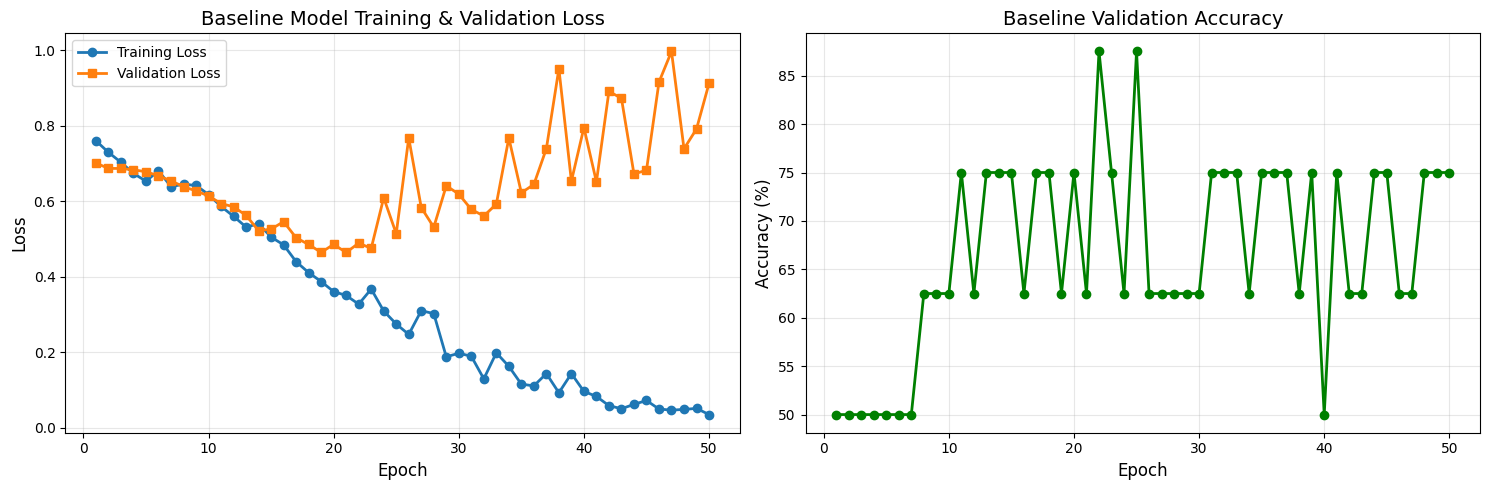


Final Results:
Best Validation Accuracy: 87.50% at Epoch 22
Final Validation Accuracy: 75.00%


In [8]:
# 3. INITIALIZE THE BASELINE MODEL (FROM SCRATCH)
# We initialize a NEW GraphAutoencoder to get a "fresh" encoder with random weights
fresh_gae = GraphAutoencoder(num_nodes=100, input_dim=100, hidden_dim=64, embedding_dim=128)
baseline_model = Baseline_GNN(gae_encoder=fresh_gae.encoder, embedding_dim=128)

optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

# Note: Since the Baseline_GNN model ends with a Sigmoid, we use BCELoss.
# If you removed Sigmoid, you would use BCEWithLogitsLoss for better numerical stability.
loss_fn = torch.nn.BCELoss()

# 4. Start the training loop
#    - for epoch in range(num_epochs):
#    -   for (data, label) in train_dataloader:
#    -     # ... 1. Get prediction (prediction = baseline_model(data))
#    -     # ... 2. Calculate loss
#    -     # ... 3. Backpropagate and update
#    -   # ... Run validation loop

num_epochs = 50
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    baseline_model.train()
    total_train_loss = 0
    for data, labels in train_loader:
        optimizer.zero_grad()
        
        # Forward pass (Only target data, no retrieval)
        predictions = baseline_model(data.x, data.edge_index, data.edge_weight, data.batch)
        
        loss = loss_fn(predictions.squeeze(), labels.float())
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # --- VALIDATION PHASE ---
    baseline_model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, labels in val_loader:
            preds = baseline_model(data.x, data.edge_index, data.edge_weight, data.batch)
            val_loss = loss_fn(preds.squeeze(), labels.float())
            total_val_loss += val_loss.item()
            
            # Calculate accuracy
            predicted_class = (preds > 0.5).float()
            correct += (predicted_class.squeeze() == labels).sum().item()
            total += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    
    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

# 5. Save the trained baseline model
torch.save(baseline_model.state_dict(), os.path.join(output_dir, 'baseline_model.pth'))
print("Baseline Model (Ab-Initio) Training Complete.")

# 6. Visualize Training Metrics
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot losses
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Training Loss', linewidth=2)
ax1.plot(range(1, num_epochs + 1), val_losses, marker='s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Baseline Model Training & Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2.plot(range(1, num_epochs + 1), val_accuracies, marker='o', color='green', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Baseline Validation Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'baseline_training_metrics.png'), dpi=300)
plt.show()

# Print final metrics
print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}% at Epoch {val_accuracies.index(max(val_accuracies)) + 1}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")